In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [2]:
conn=sqlite3.connect('inventory.db')
df=pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,32076.0,1.065065e+04,18752.934461,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,32076.0,1.803923e+04,12661.792300,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,32076.0,2.438530e+01,109.265968,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,32076.0,3.564367e+01,148.241394,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,32076.0,8.473605e+02,664.288501,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,32076.0,3.140887e+03,11094.740853,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,32076.0,3.010669e+04,123063.962691,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,32076.0,3.077482e+03,10952.509909,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,32076.0,4.223907e+04,167650.038926,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,32076.0,1.879378e+04,44951.371874,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


In [4]:
df.shape

(32076, 18)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,32076.0,1.065065e+04,18752.934461,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,32076.0,1.803923e+04,12661.792300,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,32076.0,2.438530e+01,109.265968,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,32076.0,3.564367e+01,148.241394,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,32076.0,8.473605e+02,664.288501,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,32076.0,3.140887e+03,11094.740853,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,32076.0,3.010669e+04,123063.962691,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,32076.0,3.077482e+03,10952.509909,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,32076.0,4.223907e+04,167650.038926,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,32076.0,1.879378e+04,44951.371874,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


In [6]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


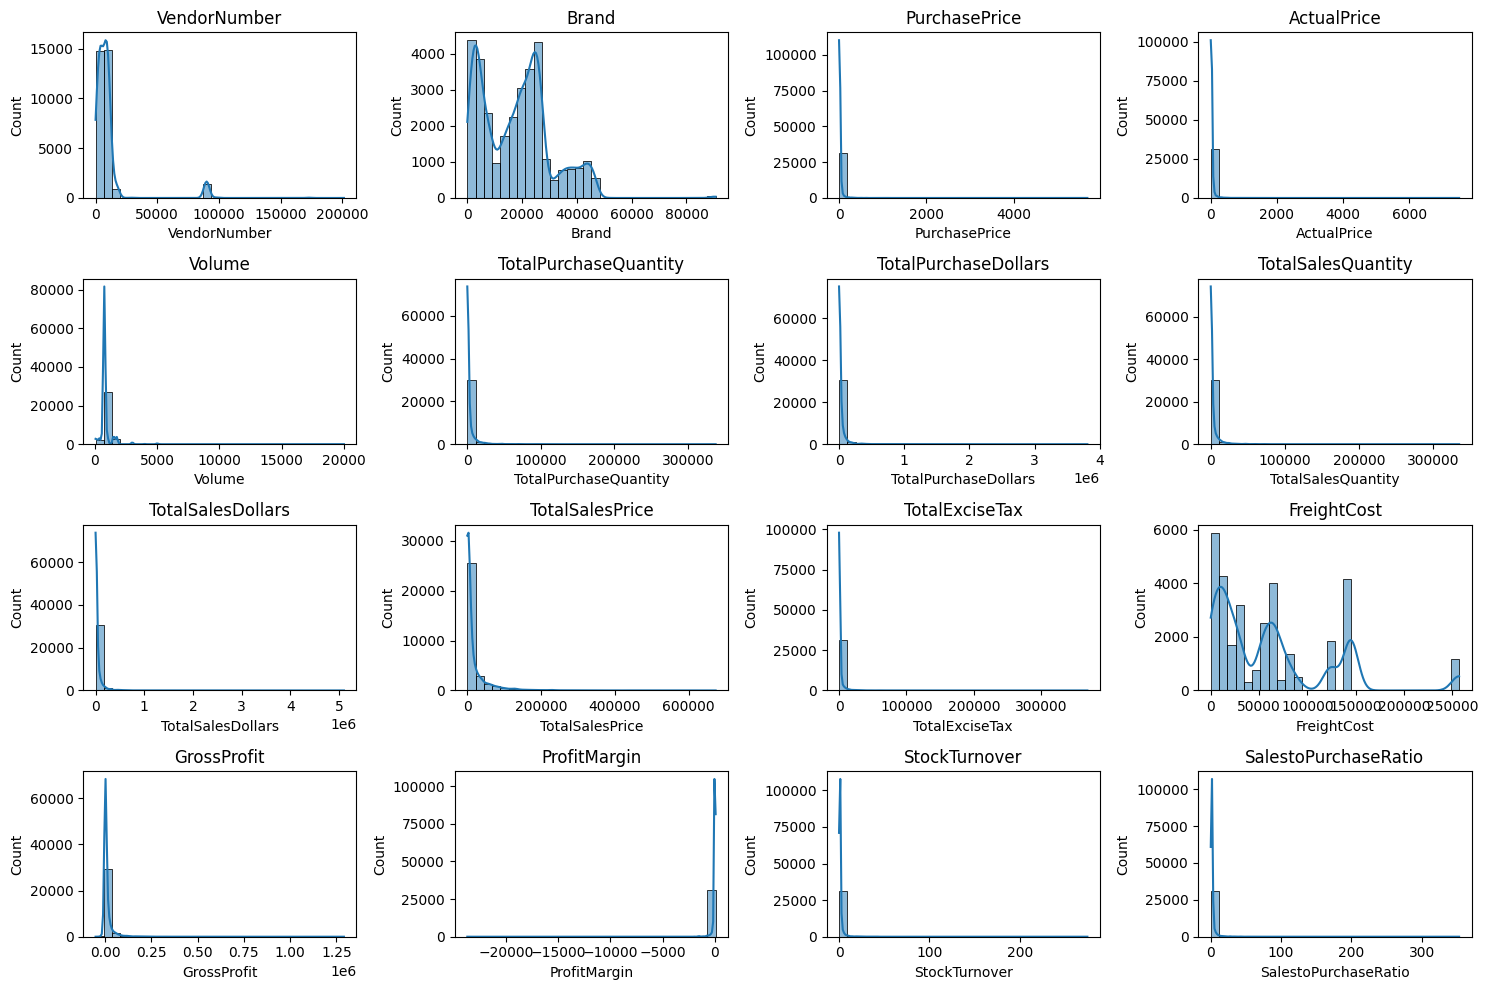

In [7]:
numerical_cols=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1),
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

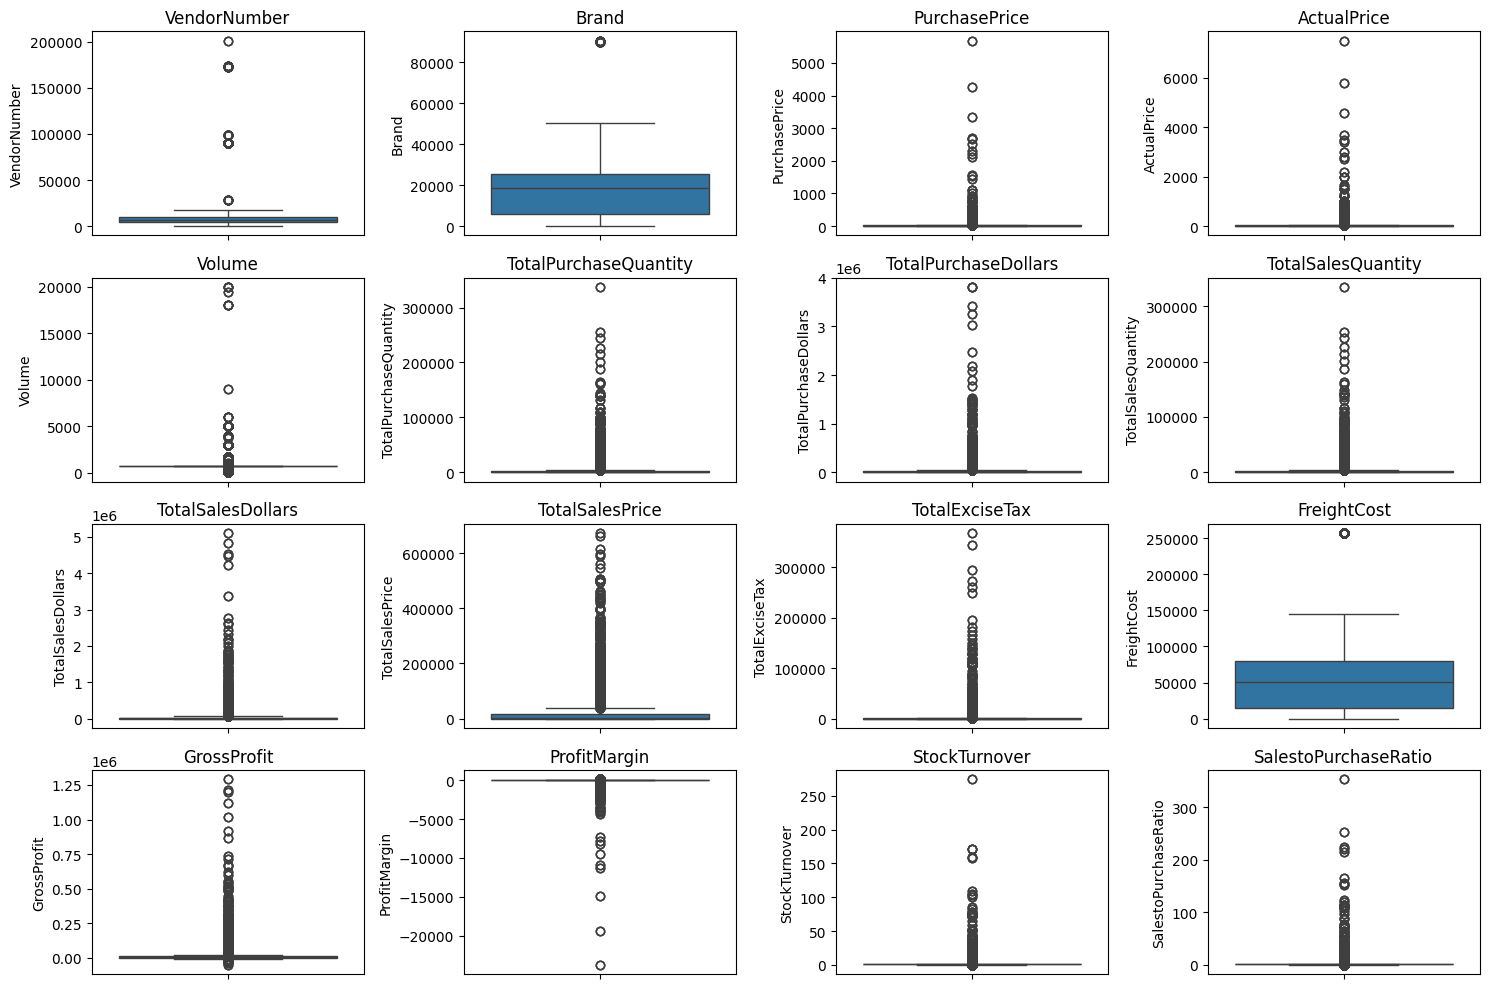

In [8]:
numerical_cols=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1),
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

**Negative & Zero Values:**

* **Gross Profit:** Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price..
* **Profit Margin:** Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
* **Total Sales Quantity & Sales Dollars:** Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

**Outliers Indicated by High Standard Deviations:**

* **Purchase & Actual Prices:** The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
* **Freight Cost:** Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
* **Stock Turnover:** Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [9]:
df=pd.read_sql_query("""select * from vendor_sales_summary
   where GrossProfit >0 and
   ProfitMargin >0 and
   TotalSalesQuantity >0 """,conn
)

In [10]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25690,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
25691,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
25692,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
25693,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


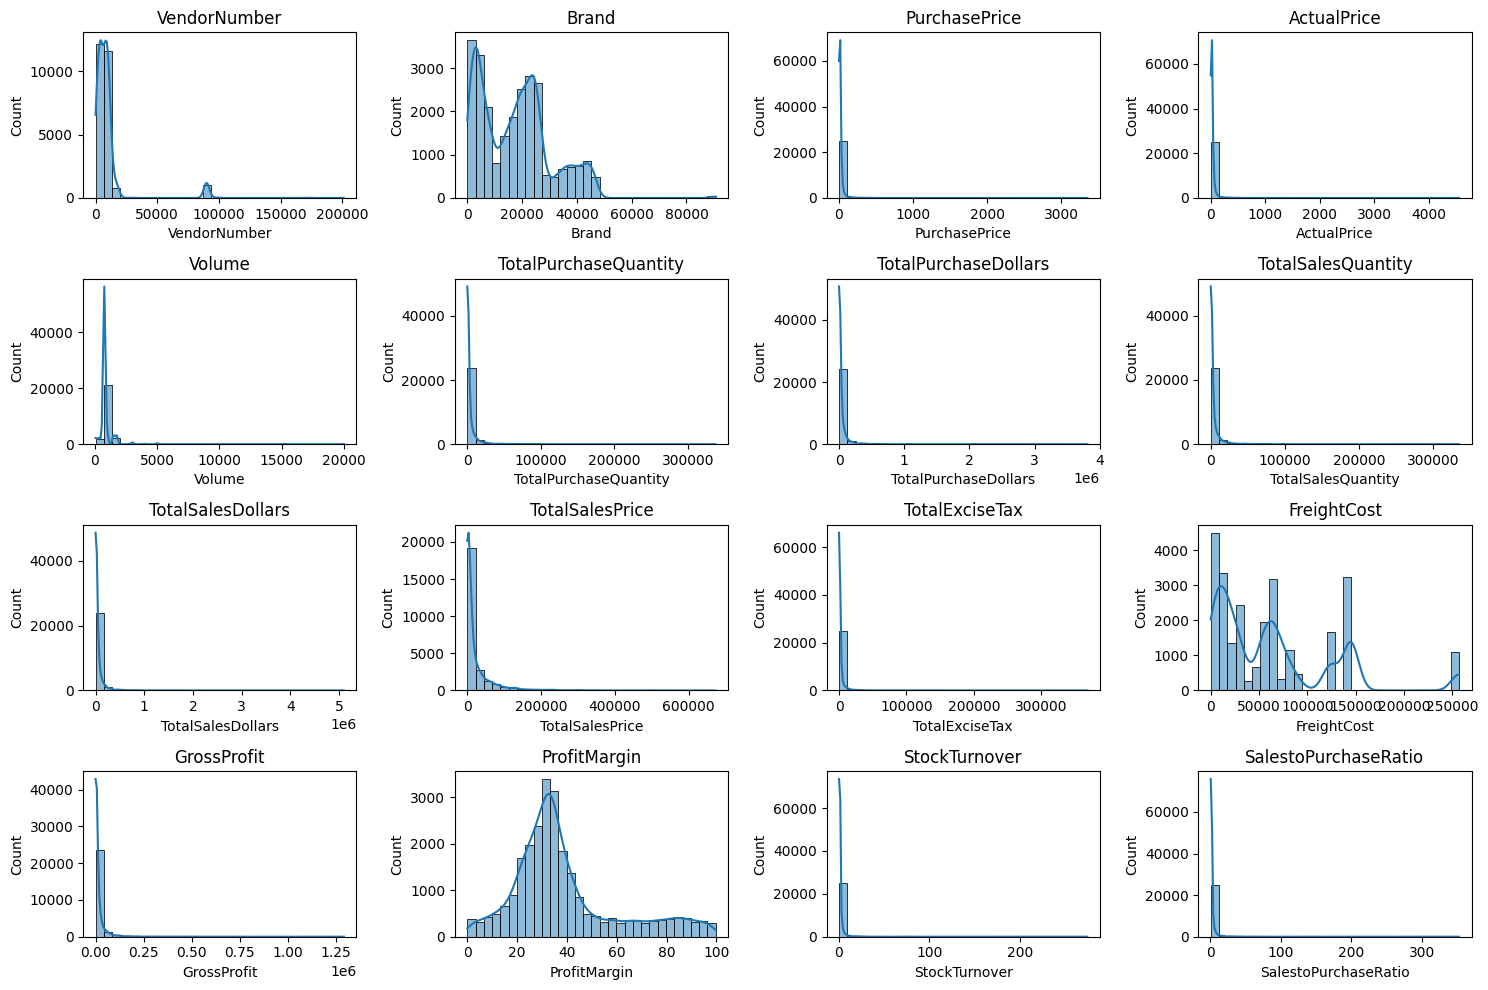

In [11]:
numerical_cols=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1),
    sns.histplot(df[col],kde='True',bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

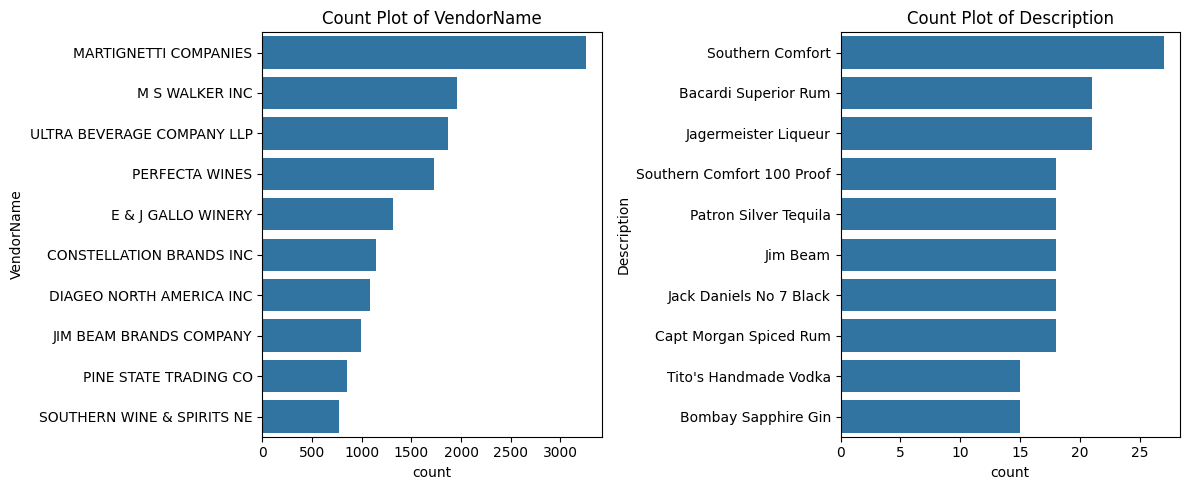

In [12]:
categorical_cols=("VendorName","Description")

plt.figure(figsize=(12,5))
for i,col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

In [13]:
correlation_matrix=df[numerical_cols].corr()
correlation_matrix

,VendorNumber,Brand,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
VendorNumber,1.000000,0.080837,-0.018545,-0.017982,0.001970,-0.059278,-0.047169,-0.059919,-0.050759,-0.074869,-0.033071,-0.214266,-0.058735,-0.018220,-0.004733,-0.003305
Brand,0.080837,1.000000,-0.035821,-0.021094,-0.001681,-0.141107,-0.153719,-0.142366,-0.147269,-0.245161,-0.161712,-0.163877,-0.125197,0.073257,-0.019914,-0.006662
PurchasePrice,-0.018545,-0.035821,1.000000,0.994893,0.028466,-0.046420,-0.010395,-0.046811,-0.012157,-0.007506,-0.015916,-0.000320,-0.016485,0.038337,0.003125,0.001975
ActualPrice,-0.017982,-0.021094,0.994893,1.000000,0.032171,-0.050439,-0.014009,-0.050840,-0.015522,-0.013423,-0.019226,-0.004498,-0.019073,0.048165,0.003686,0.002990
Volume,0.001970,-0.001681,0.028466,0.032171,1.000000,0.010968,0.095907,0.010367,0.097975,0.135661,0.130276,-0.016281,0.100337,-0.055511,-0.038814,-0.038587
TotalPurchaseQuantity,-0.059278,-0.141107,-0.046420,-0.050439,0.010968,1.000000,0.673769,0.999119,0.685415,0.546468,0.617508,0.168105,0.694383,-0.121492,-0.047703,-0.049877
TotalPurchaseDollars,-0.047169,-0.153719,-0.010395,-0.014009,0.095907,0.673769,1.000000,0.671113,0.996734,0.822529,0.882751,0.152732,0.955625,-0.121156,-0.040859,-0.043484
TotalSalesQuantity,-0.059919,-0.142366,-0.046811,-0.050840,0.010367,0.999119,0.671113,1.000000,0.683869,0.543643,0.617111,0.169359,0.695862,-0.111568,-0.043700,-0.046023
TotalSalesDollars,-0.050759,-0.147269,-0.012157,-0.015522,0.097975,0.685415,0.996734,0.683869,1.000000,0.827066,0.873089,0.151684,0.976292,-0.108145,-0.040306,-0.042589
TotalSalesPrice,-0.074869,-0.245161,-0.007506,-0.013423,0.135661,0.546468,0.822529,0.543643,0.827066,1.000000,0.665277,0.197879,0.812378,-0.179948,-0.065544,-0.069349


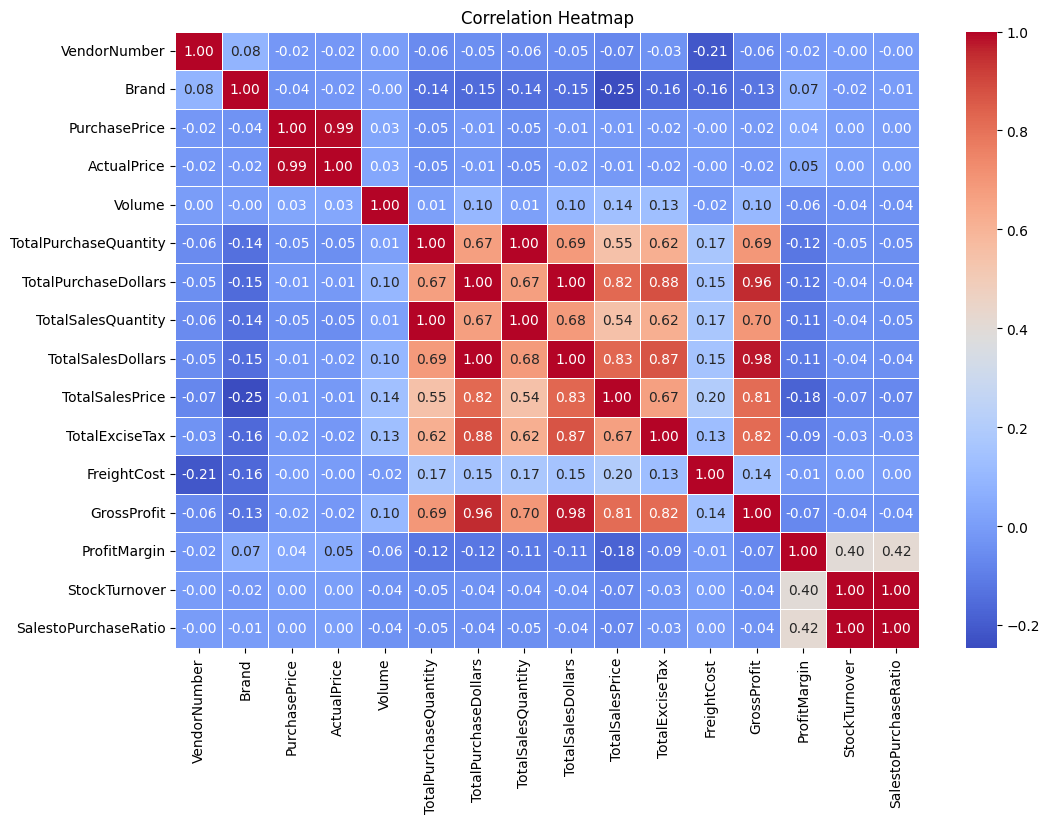

In [14]:
plt.figure(figsize=(12,8))
correlation_matrix=df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Correlation Insights

* PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
* Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
* Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
* StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

**Brands with lowest sales and highest profitmargin**

In [22]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'GrossProfit': 'sum',
    'ProfitMargin':'mean'
}).reset_index()

In [23]:
brand_performance

,Description,TotalSalesDollars,GrossProfit,ProfitMargin
0,(RI) 1,64557.27,11659.47,18.060661
1,.nparalleled Svgn Blanc,3283.89,984.45,29.978166
2,10 Span Cab Svgn CC,8111.67,1698.39,20.937612
3,10 Span Chard CC,9976.68,2774.16,27.806445
4,10 Span Pnt Gris Monterey Cy,6246.66,2013.06,32.226182
...,...,...,...,...
7702,Zorvino Vyds Sangiovese,31737.09,9370.59,29.525675
7703,Zuccardi Q Malbec,4917.54,1179.30,23.981503
7704,Zum Rsl,32572.02,10642.92,32.675038
7705,Zwack Liqueur,683.64,113.85,16.653502


In [24]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

In [25]:
low_sales_threshold

1680.897

In [26]:
high_margin_threshold

64.97017552750111

In [27]:
target_brands=brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold ) &  
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with low sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but High Profit Margins:


,Description,TotalSalesDollars,GrossProfit,ProfitMargin
6199,Santa Rita Organic Svgn Bl,29.97,19.92,66.466466
2369,Debauchery Pnt Nr,34.74,22.92,65.975820
2070,Concannon Glen Ellen Wh Zin,47.85,39.93,83.448276
2188,Crown Royal Apple,83.58,75.06,89.806174
6237,Sauza Sprklg Wild Berry Marg,83.88,68.91,82.153076
...,...,...,...,...
5074,Nanbu Bijin Southern Beauty,1607.04,1233.36,76.747312
2271,Dad's Hat Rye Whiskey,1616.67,1323.27,81.851584
57,A Bichot Clos Marechaudes,1619.82,1097.28,67.740860
6245,Sbragia Home Ranch Merlot,1649.25,1095.84,66.444748


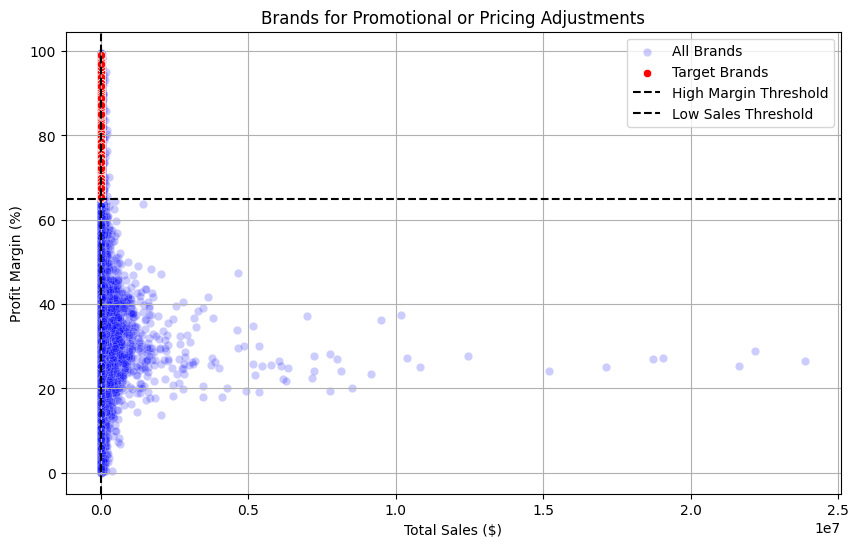

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color="blue",
    label="All Brands",
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color="red",
    label="Target Brands"
)

plt.axhline(
    high_margin_threshold,
    linestyle='--',
    color='black',
    label="High Margin Threshold"
)

plt.axvline(
    low_sales_threshold,
    linestyle='--',
    color='black',
    label="Low Sales Threshold"
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000]

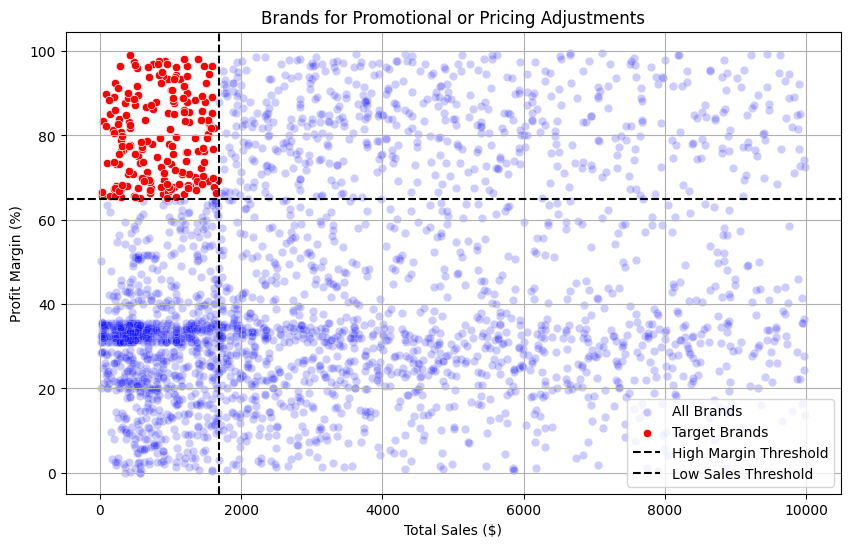

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color="blue",
    label="All Brands",
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color="red",
    label="Target Brands"
)

plt.axhline(
    high_margin_threshold,
    linestyle='--',
    color='black',
    label="High Margin Threshold"
)

plt.axvline(
    low_sales_threshold,
    linestyle='--',
    color='black',
    label="Low Sales Threshold"
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)

plt.show()

**Vendors and Brands performing demonstrating highest sales performance**

In [33]:
top_vendors=df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands=df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

In [34]:
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      2.039703e+08
MARTIGNETTI COMPANIES         1.179911e+08
PERNOD RICARD USA             9.618959e+07
JIM BEAM BRANDS COMPANY       9.426906e+07
BACARDI USA INC               7.456445e+07
CONSTELLATION BRANDS INC      7.265624e+07
E & J GALLO WINERY            5.519970e+07
BROWN-FORMAN CORP             5.474169e+07
ULTRA BEVERAGE COMPANY LLP    4.950763e+07
M S WALKER INC                4.411938e+07
Name: TotalSalesDollars, dtype: float64

In [37]:
top_brands

Description
Jack Daniels No 7 Black    2.389424e+07
Tito's Handmade Vodka      2.219897e+07
Grey Goose Vodka           2.162882e+07
Capt Morgan Spiced Rum     1.906896e+07
Absolut 80 Proof           1.873426e+07
Jameson Irish Whiskey      1.714728e+07
Ketel One Vodka            1.521025e+07
Baileys Irish Cream        1.245037e+07
Kahlua                     1.081458e+07
Tanqueray                  1.037009e+07
Name: TotalSalesDollars, dtype: float64

In [38]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value>=1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [39]:
top_vendors.apply(lambda x: format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      203.97M
MARTIGNETTI COMPANIES         117.99M
PERNOD RICARD USA              96.19M
JIM BEAM BRANDS COMPANY        94.27M
BACARDI USA INC                74.56M
CONSTELLATION BRANDS INC       72.66M
E & J GALLO WINERY             55.20M
BROWN-FORMAN CORP              54.74M
ULTRA BEVERAGE COMPANY LLP     49.51M
M S WALKER INC                 44.12M
Name: TotalSalesDollars, dtype: object

In [40]:
top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    23.89M
Tito's Handmade Vodka      22.20M
Grey Goose Vodka           21.63M
Capt Morgan Spiced Rum     19.07M
Absolut 80 Proof           18.73M
Jameson Irish Whiskey      17.15M
Ketel One Vodka            15.21M
Baileys Irish Cream        12.45M
Kahlua                     10.81M
Tanqueray                  10.37M
Name: TotalSalesDollars, dtype: object

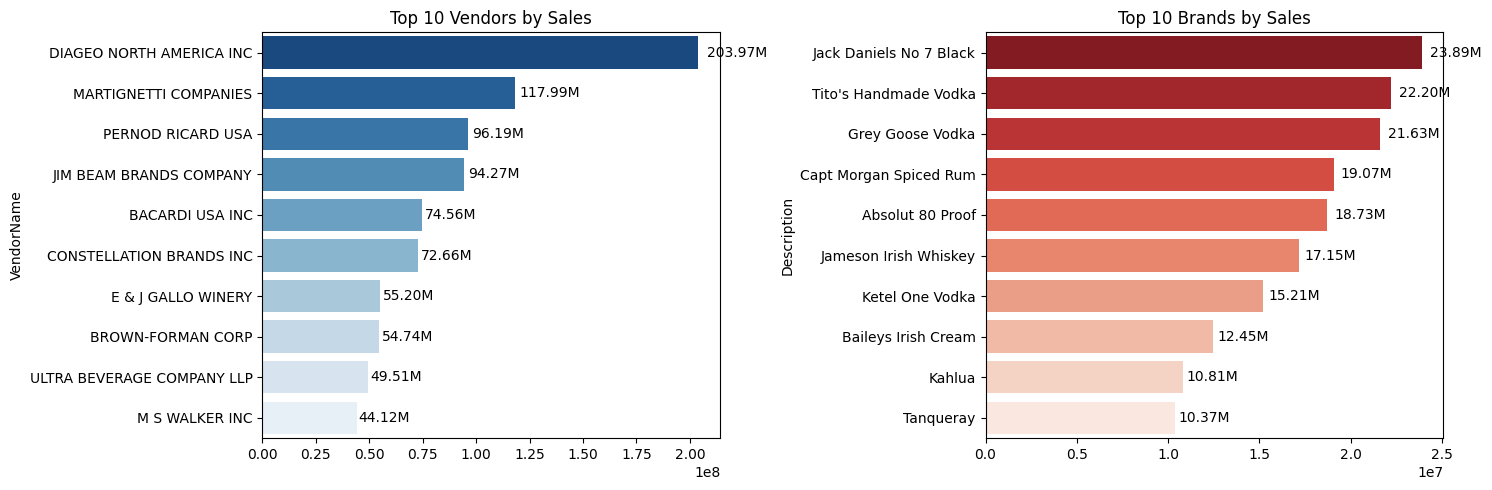

In [41]:
plt.figure(figsize=(15, 5))

# Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

**Vendors contributing most to total purchase dollars**

In [43]:
vendor_performance=df.groupby('VendorName').agg(
    {
        'TotalPurchaseDollars':'sum',
        'GrossProfit':'sum',
        'TotalSalesDollars':'sum'
    }
).reset_index()

In [44]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,1338.48,7.751100e+02,2.113590e+03
1,ALISA CARR BEVERAGES,77094.36,2.363185e+05,3.134128e+05
2,ALTAMAR BRANDS LLC,35118.60,1.200183e+04,4.712043e+04
3,AMERICAN SPIRITS EXCHANGE,2802.24,1.731240e+03,4.533480e+03
4,AMERICAN VINTAGE BEVERAGE,313307.04,1.055036e+05,4.188106e+05
...,...,...,...,...
114,WEIN BAUER INC,128083.92,4.056747e+04,1.686514e+05
115,WESTERN SPIRITS BEVERAGE CO,895250.58,3.205139e+05,1.215764e+06
116,WILLIAM GRANT & SONS INC,17629614.78,5.080014e+06,2.270963e+07
117,WINE GROUP INC,15611403.51,9.300726e+06,2.491213e+07


In [57]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [58]:
vendor_performance['PurchaseContribution%']

25     16.300334
57      8.297719
68      7.760548
46      7.644435
6       5.671926
         ...    
33      0.000042
107     0.000039
85      0.000025
16      0.000018
35      0.000006
Name: PurchaseContribution%, Length: 119, dtype: float64

In [59]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,1.502917e+08,53678619.78,2.039703e+08,16.300334
57,MARTIGNETTI COMPANIES,7.650629e+07,41484790.59,1.179911e+08,8.297719
68,PERNOD RICARD USA,7.155349e+07,24636096.06,9.618959e+07,7.760548
46,JIM BEAM BRANDS COMPANY,7.048291e+07,23786148.42,9.426906e+07,7.644435
6,BACARDI USA INC,5.229606e+07,22268390.64,7.456445e+07,5.671926
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,3.859200e+02,596.85,9.827700e+02,0.000042
107,UNCORKED,3.562200e+02,174.60,5.308200e+02,0.000039
85,SILVER MOUNTAIN CIDERS,2.315400e+02,795.99,1.027530e+03,0.000025
16,CAPSTONE INTERNATIONAL,1.639200e+02,576.69,7.406100e+02,0.000018


In [60]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [61]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,1.502917e+08,53678619.78,2.039703e+08,16.30
57,MARTIGNETTI COMPANIES,7.650629e+07,41484790.59,1.179911e+08,8.30
68,PERNOD RICARD USA,7.155349e+07,24636096.06,9.618959e+07,7.76
46,JIM BEAM BRANDS COMPANY,7.048291e+07,23786148.42,9.426906e+07,7.64
6,BACARDI USA INC,5.229606e+07,22268390.64,7.456445e+07,5.67
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,3.859200e+02,596.85,9.827700e+02,0.00
107,UNCORKED,3.562200e+02,174.60,5.308200e+02,0.00
85,SILVER MOUNTAIN CIDERS,2.315400e+02,795.99,1.027530e+03,0.00
16,CAPSTONE INTERNATIONAL,1.639200e+02,576.69,7.406100e+02,0.00


In [62]:
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,150.29M,53.68M,203.97M,16.30
57,MARTIGNETTI COMPANIES,76.51M,41.48M,117.99M,8.30
68,PERNOD RICARD USA,71.55M,24.64M,96.19M,7.76
46,JIM BEAM BRANDS COMPANY,70.48M,23.79M,94.27M,7.64
6,BACARDI USA INC,52.30M,22.27M,74.56M,5.67
20,CONSTELLATION BRANDS INC,45.82M,26.84M,72.66M,4.97
11,BROWN-FORMAN CORP,39.72M,15.02M,54.74M,4.31
30,E & J GALLO WINERY,36.21M,18.99M,55.20M,3.93
106,ULTRA BEVERAGE COMPANY LLP,33.50M,16.01M,49.51M,3.63
53,M S WALKER INC,29.29M,14.83M,44.12M,3.18


In [69]:
round(top_vendors['PurchaseContribution%'].sum(),2)

65.69

In [67]:
top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,150.29M,53.68M,203.97M,16.30,16.30
57,MARTIGNETTI COMPANIES,76.51M,41.48M,117.99M,8.30,24.60
68,PERNOD RICARD USA,71.55M,24.64M,96.19M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,70.48M,23.79M,94.27M,7.64,40.00
6,BACARDI USA INC,52.30M,22.27M,74.56M,5.67,45.67
20,CONSTELLATION BRANDS INC,45.82M,26.84M,72.66M,4.97,50.64
11,BROWN-FORMAN CORP,39.72M,15.02M,54.74M,4.31,54.95
30,E & J GALLO WINERY,36.21M,18.99M,55.20M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,33.50M,16.01M,49.51M,3.63,62.51
53,M S WALKER INC,29.29M,14.83M,44.12M,3.18,65.69


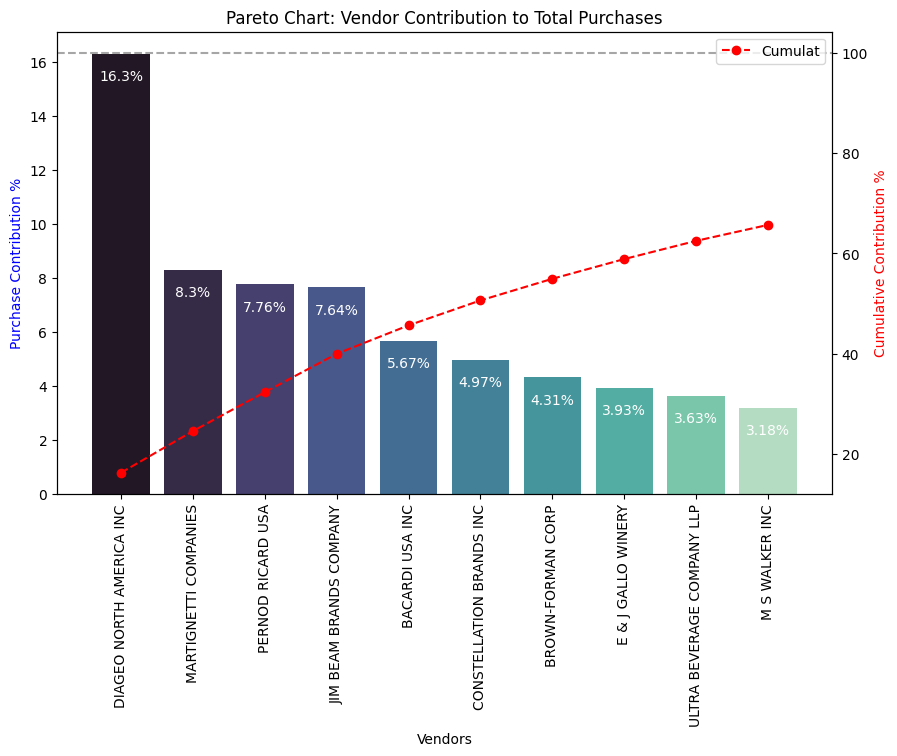

In [68]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulat')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

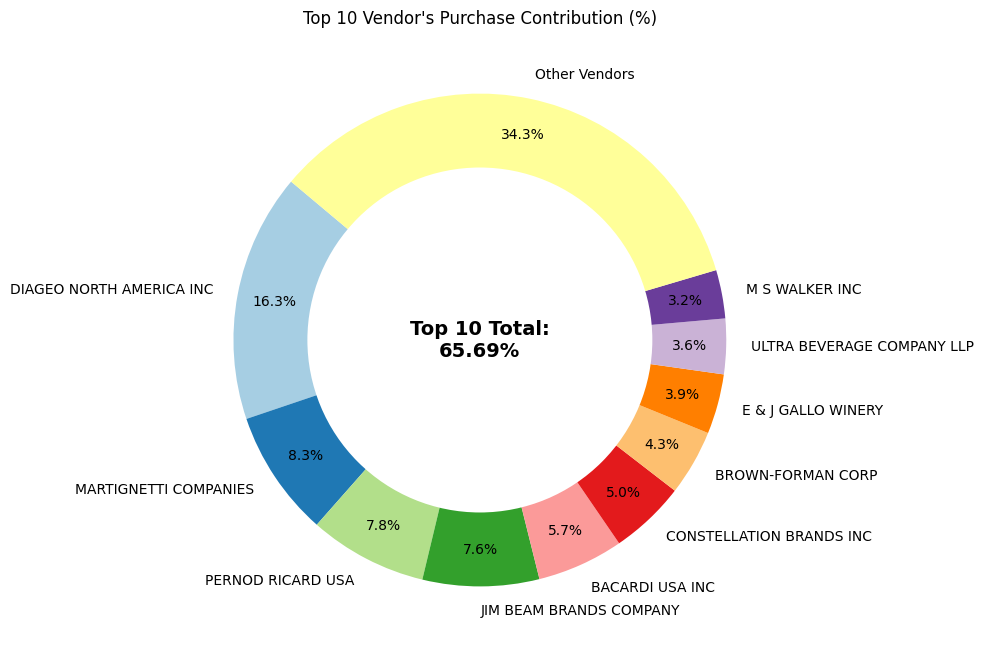

In [71]:
vendors = list(top_vendors['VendorName'].values)
purchasecontributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchasecontributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchasecontributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchasecontributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

**Do purchasing in bulk decreases unitpurchaseprice and how it affects**

In [72]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [73]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25690,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
25691,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
25692,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74
25693,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47


In [74]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [76]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice,OrderSize
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27,Large
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17,Large
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25690,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32,Small
25691,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39,Small
25692,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74,Small
25693,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47,Small


In [77]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.057543
Medium,15.486414
Large,10.777625


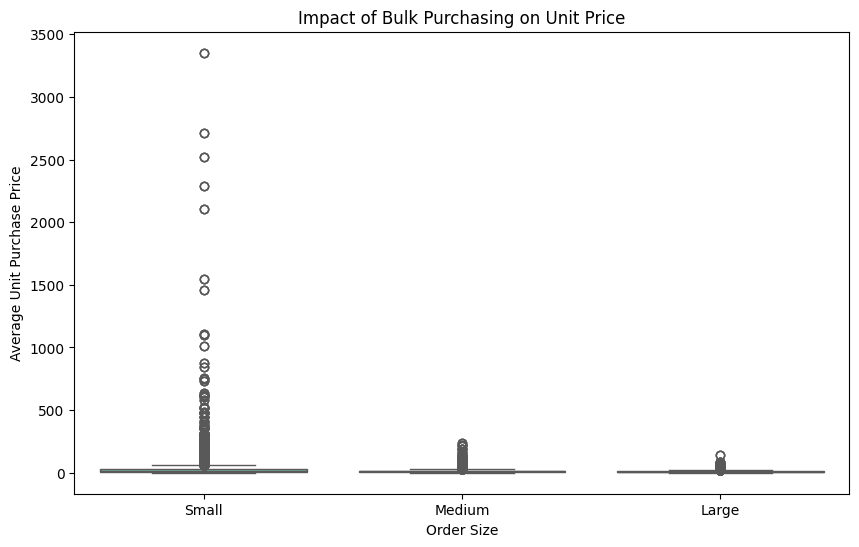

In [78]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

* Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
* The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
* This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

**Which vendors have low inventory turnover, indicating excess stock and slow-moving products?**

In [95]:
df[df['StockTurnover']<1].groupby('VendorName')['StockTurnover'].mean().sort_values(ascending=True).head(10)

VendorName
ALISA CARR BEVERAGES           0.615385
HIGHLAND WINE MERCHANTS LLC    0.708333
PARK STREET IMPORTS LLC        0.751306
Circa Wines                    0.755676
Dunn Wine Brokers              0.766022
CENTEUR IMPORTS LLC            0.773953
SMOKY QUARTZ DISTILLERY LLC    0.783835
TAMWORTH DISTILLING            0.797078
THE IMPORTED GRAPE LLC         0.807569
WALPOLE MTN VIEW WINERY        0.820548
Name: StockTurnover, dtype: float64

In [85]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 8.12M


In [96]:
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

In [106]:
inventory_value_per_vendor

,VendorName,UnsoldInventoryValue
45,JEWELL TOWNE VINEYARDS,9.33K
27,DJINN SPIRITS LLC,9.13K
105,TY KU LLC,863.0999999999999
104,TRINCHERO FAMILY ESTATES,83.71K
49,LABELLE VYDS AND WINERY,8.65K
...,...,...
94,SURVILLE ENTERPRISES CORP,-12976.8
1,ALISA CARR BEVERAGES,-129454.44
24,DIAGEO CHATEAU ESTATE WINES,-116993.94
71,POVERTY LANE ORCHARDS,-10912.65


In [112]:

inventory_value_per_vendor = (df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index())



inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by="UnsoldInventoryValue", ascending=False
)
inventory_value_per_vendor["UnsoldInventoryValue"] = (
    inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,2.17M
46,JIM BEAM BRANDS COMPANY,1.66M
68,PERNOD RICARD USA,1.41M
116,WILLIAM GRANT & SONS INC,1.21M
30,E & J GALLO WINERY,684.85K
79,SAZERAC CO INC,595.31K
11,BROWN-FORMAN CORP,533.20K
20,CONSTELLATION BRANDS INC,400.85K
61,MOET HENNESSY USA INC,379.43K
77,REMY COINTREAU USA INC,355.79K


**95% confidence intervals for profit margins of top-performing and low-performing vendors**

In [113]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [114]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [115]:
top_vendors

0        25.297693
1        21.062810
2        24.675786
3        27.139908
4        28.412764
           ...    
20653    79.684817
20811    85.782102
21881    93.085860
22050    95.012530
22180    94.271857
Name: ProfitMargin, Length: 6426, dtype: float64

In [116]:
low_vendors

5631      4.111764
5652      6.145626
5701     12.007271
5704      1.677308
5724      7.239599
           ...    
25690    83.448276
25691    96.436186
25692    25.252525
25693    98.974037
25694    99.166079
Name: ProfitMargin, Length: 6426, dtype: float64

In [117]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.92, 31.42), Mean: 31.17
Low Vendors 95% CI: (40.93, 42.17), Mean: 41.55


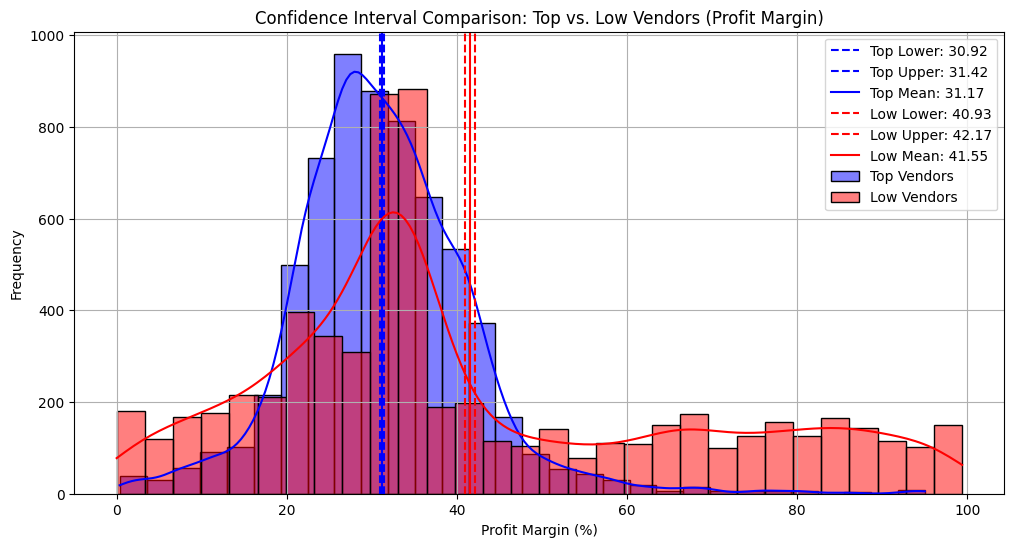

In [118]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

* The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
* This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
* For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments & cost optimization.
* For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

In [119]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H0: No significant difference in profit margins.")

T-Statistic: -30.5650, P-Value: 0.0000
Reject H0: There is a significant difference in profit margins between top and low-performing vendors.
